In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
from collections import Counter
from tabulate import tabulate

# Beat Annotations

| Symbol | Meaning                                   |
| ------ | ----------------------------------------- |
| · or N | Normal beat                               |
| L      | Left bundle branch block beat             |
| R      | Right bundle branch block beat            |
| A      | Atrial premature beat                     |
| a      | Aberrated atrial premature beat           |
| J      | Nodal (junctional) premature beat         |
| S      | Supraventricular premature beat           |
| V      | Premature ventricular contraction         |
| F      | Fusion of ventricular and normal beat     |
| \[     | Start of ventricular flutter/fibrillation |
| !      | Ventricular flutter wave                  |
| ]      | End of ventricular flutter/fibrillation   |
| e      | Atrial escape beat                        |
| j      | Nodal (junctional) escape beat            |
| E      | Ventricular escape beat                   |
| /      | Paced beat                                |
| f      | Fusion of paced and normal beat           |
| x      | Non-conducted P-wave (blocked APB)        |
| Q      | Unclassifiable beat                       |
| \|     | Isolated QRS-like artifact                |

# Rhythm Annotations

| Symbol | Meaning                          |
| ------ | -------------------------------- |
| (AB    | Atrial bigeminy                  |
| (AFIB  | Atrial fibrillation              |
| (AFL   | Atrial flutter                   |
| (B     | Ventricular bigeminy             |
| (BII   | 2° heart block                   |
| (IVR   | Idioventricular rhythm           |
| (N     | Normal sinus rhythm              |
| (NOD   | Nodal (A-V junctional) rhythm    |
| (P     | Paced rhythm                     |
| (PREX  | Pre-excitation (WPW)             |
| (SBR   | Sinus bradycardia                |
| (SVTA  | Supraventricular tachyarrhythmia |
| (T     | Ventricular trigeminy            |
| (VFL   | Ventricular flutter              |
| (VT    | Ventricular tachycardia          |

# Signal Quality & Comments

| Symbol    | Meaning                                          |
| --------- | ------------------------------------------------ |
| qq        | Signal quality change (e.g., `cq` = clean/noisy) |
| U         | Extreme noise or signal loss                     |
| M / MISSB | Missed beat                                      |
| P / PSE   | Pause                                            |
| T / TS    | Tape slippage                                    |

https://archive.physionet.org/physiobank/annotations.shtml

In [4]:
path = "../dataset/mitbih_full/"
# Define the record ranges
record_ids = list(range(100, 109)) + list(range(111, 119)) + list(range(121, 124)) + list(range(200, 203)) + [205] \
        + list(range(207, 210)) + list(range(212, 215)) + [217] + list(range(219, 223))  \
        + [228] + list(range(230, 234))

records = []
symbol_counter = Counter()
for record_id in record_ids:
    record = wfdb.rdrecord(f"{path}{record_id}", sampfrom = 0)
    #print(record.__dict__)
    annotation = wfdb.rdann(f"{path}{record_id}", 'atr')
    symbol_counter.update(annotation.symbol)
    #print(annotation.__dict__)
    record_dict = {
        'record_name': record.record_name,
        'p_signal': record.p_signal,  # numpy array of the physical signals
        'fs': record.fs,              # sampling frequency
        'sig_name': record.sig_name,  # signal names (e.g., ['MLII', 'V5'])
        'units': record.units,        # signal units (e.g., ['mV', 'mV'])
        'annotation': annotation.sample,
        'symbol': annotation.symbol,
    }
    records.append(record_dict)

# Display results
print("All unique symbols found:")
print(sorted(symbol_counter.keys()))

print("\nCounts per symbol:")
# Prepare data for table display
table_data = [(sym, count) for sym, count in sorted(symbol_counter.items())]

# Print table with headers
print(tabulate(table_data, headers=["Symbol", "Count"], tablefmt="grid"))

All unique symbols found:
['!', '"', '+', '/', 'A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', '[', ']', 'a', 'f', 'j', 'x', '|', '~']

Counts per symbol:
+----------+---------+
| Symbol   |   Count |
+==========+=========+
| !        |     472 |
+----------+---------+
| "        |     435 |
+----------+---------+
| +        |    1076 |
+----------+---------+
| /        |    7028 |
+----------+---------+
| A        |    2469 |
+----------+---------+
| E        |     105 |
+----------+---------+
| F        |     770 |
+----------+---------+
| J        |       4 |
+----------+---------+
| L        |    5583 |
+----------+---------+
| N        |   60633 |
+----------+---------+
| Q        |      29 |
+----------+---------+
| R        |    5728 |
+----------+---------+
| S        |       2 |
+----------+---------+
| V        |    5323 |
+----------+---------+
| [        |       6 |
+----------+---------+
| ]        |       6 |
+----------+---------+
| a        |     125 |
+----------+---

{'V', '+', 'N', 'A'}


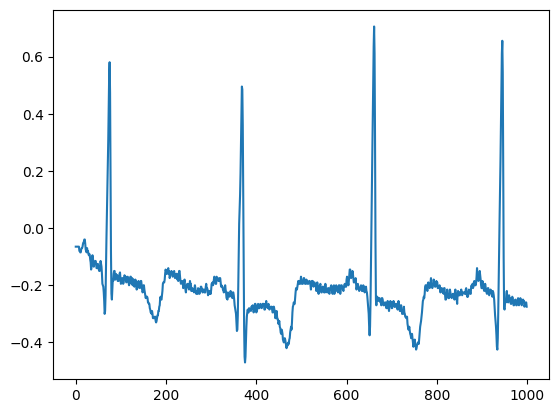

In [5]:
ann = wfdb.rdann(f'{path}100', 'atr')
print(set(ann.symbol))  # Shows all unique annotation symbols in record 100
plt.plot(records[0]["p_signal"][:, 1][:1000])